In [26]:
import numpy as np
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks, peak_prominences
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from spectral_cube import SpectralCube as sc
from sklearn.cluster import DBSCAN
from tqdm.notebook import trange
from kneed import KneeLocator
import os
import time
import warnings
from copy import deepcopy

np.seterr(divide="ignore", invalid="ignore")
np.set_printoptions(precision=10, suppress=True)
plt.rcParams.update({'figure.max_open_warning': 0})
delta_min = 1e-12

%matplotlib widget

In [27]:
# 从data cube导入数据
# HVC_229_234_4_14.fits
# HVC_219_226_-1_9.fits

file = "HVC_219_226_-1_9.fits"
hdul = fits.open(file)
hdr = hdul[0].header
wcs = WCS(hdr)
data_nan = hdul[0].data.astype(np.float64)
pixel_to_arcmin = (hdr["CDELT2"] * u.deg).to(u.arcmin).value  # 1 pixel = 1.5 arcmin

MEAN = np.nanmean(data_nan)
STD = np.nanstd(data_nan)
print("Mean:", MEAN, "Std:", STD)

data = np.nan_to_num(data_nan)  # 增加这一行可以提升DBSCAN速度至少十倍，尚未知晓原因
print("data.shape =", data.shape)

delta_v = np.float64(hdr["CDELT3"]) / 1000
print(delta_v)

cube = sc.read(hdul)
cube = cube.with_spectral_unit(u.km / u.s)
velocities = cube.spectral_axis.value
cube

# data_slab = deepcopy(data)[3478:, :, :]  # 保留[-600,-100]km/s的速度部分

# 合并相邻两个速度切片的值

# stack = data.shape[0]
# for i in range(0, stack, 2):
#     if i // 2 < stack // 2:
#         data[i // 2] = (data[i] + data[i + 1]) / 2
#
# data = data[: stack // 2]

Mean: 0.02324853234619123 Std: 0.1263316322287047
data.shape = (496, 402, 238)
-0.201283594733


SpectralCube with shape=(496, 402, 238) and unit=K:
 n_x:    238  type_x: GLON-CAR  unit_x: deg    range:   219.016947 deg:  224.941971 deg
 n_y:    402  type_y: GLAT-CAR  unit_y: deg    range:    -0.988769 deg:    9.036271 deg
 n_s:    496  type_s: VRAD      unit_s: km / s  range:      100.167 km / s:     199.803 km / s

In [28]:
# HI4PI_229_234_4_14_reproj.fits
# HI4PI_219_226_-1_9_reproj.fits

reprojected_cube = sc.read("./HI4PI/HI4PI_219_226_-1_9_reproj.fits")
hidpi_data_reproj = reprojected_cube.unmasked_data[:, :, :]

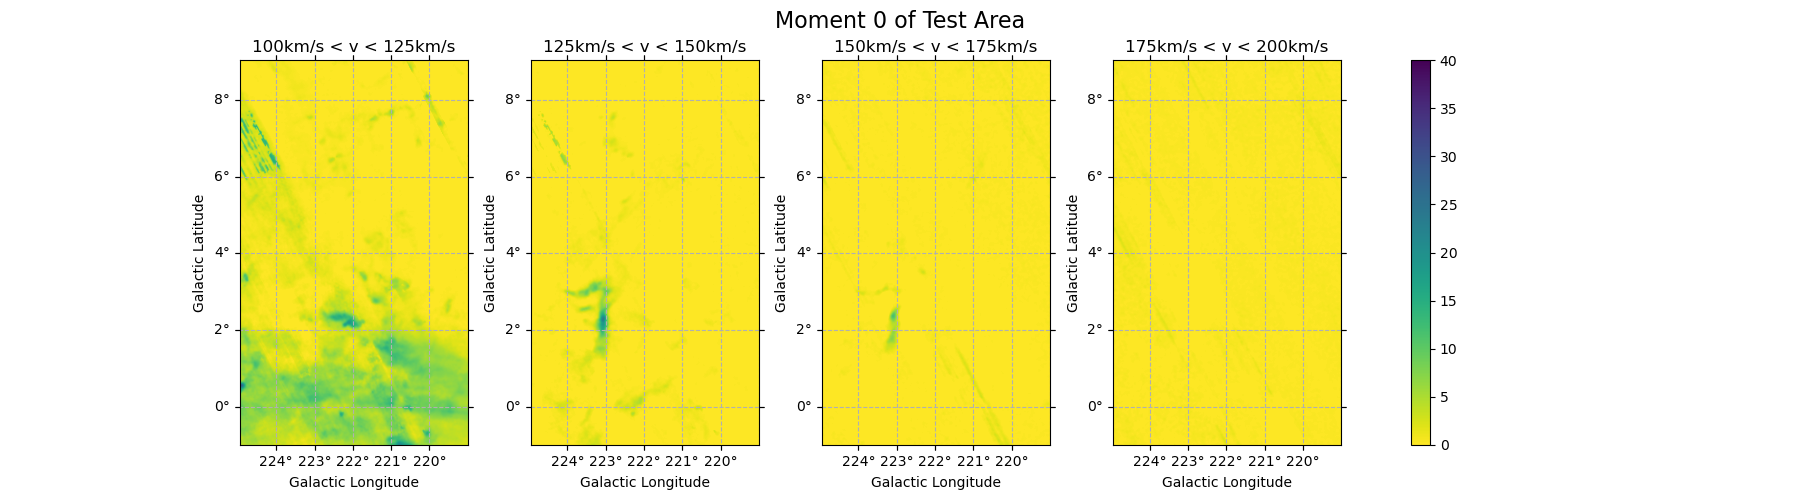

In [29]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=[18, 5],
    sharex=True,
    sharey=True,
    subplot_kw={"projection": wcs.celestial},
)

v = np.arange(100, 225, 25)
for i in range(4):
    slab = cube.spectral_slab(v[i + 1] * u.km / u.s, v[i] * u.km / u.s)
    slab_m0 = slab.moment(order=0)
    norm = simple_norm(np.array(slab_m0), vmin=0, vmax=40, stretch="linear")
    ax[i].imshow(np.array(slab_m0), norm=norm, cmap="viridis_r", origin="lower")
    ax[i].grid(linestyle="--")
    # lon = ax[i].coords[0]
    # lat = ax[i].coords[1]
    # lon.set_ticks(spacing=5.0 * u.degree)
    # lon.set_axislabel("RA (J2000)")
    # lat.set_axislabel("DEC (J2000)")
    ax[i].set_title(str(v[i]) + "km/s < v < " + str(v[i + 1]) + "km/s")
    ax[i].set_xlabel("Galactic Longitude")
    ax[i].set_ylabel("Galactic Latitude")

fig.suptitle("Moment 0 of Test Area", fontsize=16)
fig.colorbar(mpl.cm.ScalarMappable(cmap=mpl.cm.viridis_r, norm=norm), ax=ax)

plt.savefig("./Figures/data.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
def test_sigma_clip(test=False):
    if test == True:
        s_ = np.arange(2, 3.1, 0.1)
        y_ = []

        for i in trange(len(s_)):
            filtered_data = sigma_clip(data, sigma=s_[i], maxiters=10, masked=True)
            mask = filtered_data.mask  # True 的元素为 N > 3 sigma
            y_.append(np.count_nonzero(mask) / np.count_nonzero(data))

        kneedle = KneeLocator(s_, y_, S=1.0, curve="convex", direction="decreasing")

        print(round(kneedle.elbow, 3))
        print(round(kneedle.elbow_y, 3))

        fig = plt.figure()
        plt.scatter(s_, y_)
        plt.scatter(s_, kneedle.y_difference)
        plt.plot(s_, y_)
        plt.plot(s_, kneedle.y_difference)
        plt.ylim(-0.05, 1.05)
        plt.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red")
        plt.xlabel("N > x sigma")
        plt.ylabel("N(True) > N(total)")
        plt.grid(axis="y", ls="--")
        plt.show()
        return kneedle.elbow
    else:
        return 3


s = test_sigma_clip(test=False)  # test=True >> s=2.4

In [31]:
# 进行sigma clipping，保留 N > sσ 的点

clipped_data = sigma_clip(data, sigma=s, maxiters=10, masked=True)
mask = clipped_data.mask  # True 的元素为 N > sσ
index = np.transpose(np.nonzero(mask)).astype(int)  # N > sσ 的点的坐标[v,y,x]

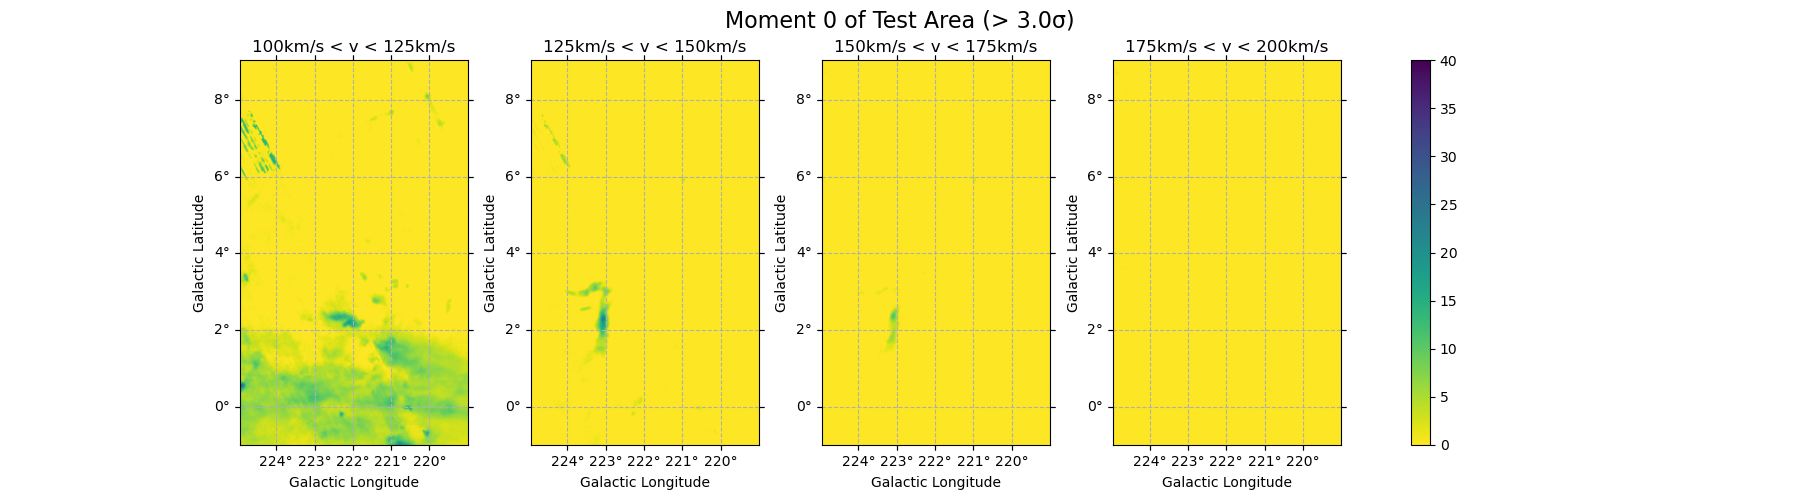

In [32]:
masked_cube = sc(mask * data_nan, wcs=wcs).with_spectral_unit(u.km / u.s)

fig, ax = plt.subplots(
    1,
    4,
    figsize=[18, 5],
    sharex=True,
    sharey=True,
    subplot_kw={"projection": wcs.celestial},
)

v = np.arange(100, 225, 25)
for i in range(4):
    slab = masked_cube.spectral_slab(v[i + 1] * u.km / u.s, v[i] * u.km / u.s)
    slab_m0 = slab.moment(order=0)
    norm = simple_norm(np.array(slab_m0), vmin=0, vmax=40, stretch="linear")
    ax[i].imshow(np.array(slab_m0), norm=norm, cmap="viridis_r", origin="lower")
    ax[i].grid(linestyle="--")
    # lon = ax[i].coords[0]
    # lat = ax[i].coords[1]
    # lon.set_ticks(spacing=5.0 * u.degree)
    # lon.set_axislabel("RA (J2000)")
    # lat.set_axislabel("DEC (J2000)")
    ax[i].set_title(str(v[i]) + "km/s < v < " + str(v[i + 1]) + "km/s")
    ax[i].set_xlabel("Galactic Longitude")
    ax[i].set_ylabel("Galactic Latitude")

fig.suptitle(f"Moment 0 of Test Area (> {s:.1f}σ)", fontsize=16)
fig.colorbar(mpl.cm.ScalarMappable(cmap=mpl.cm.viridis_r, norm=norm), ax=ax)

plt.savefig("./Figures/data_masked.png", dpi=300, bbox_inches="tight")
plt.show()

### 记录表

eps = 1, sqrt(2), sqrt(3)

min_samples = 2, 4, 6,  
              6, 9, 12, 15, 18,  
              9, 12, 15, 18

**记录每一个(eps, min_samples)参数组下，表现最好的SNR/spatial_pixels/FWHM**

N为HVC candidate数目，F为其中的假信号数目，T为其中的真信号数目

| eps | minPts | | SNR | SIZE(arcmin) | FWHM(km/s) | | N | F | T |
| - | - | - | - | - | - | - | - | - | - |
| 3 | 18 |   | 4 | 4 | 4 |   | 13 | 1 | 12 |
| 3 | 15 |   | 4 | 4 | 3.5 |   | 14 | 1 | 12 |
| 3 | 12 |   | 4 | 4 | 3.5 |   | 15 | 2 | 13 |
| 3 | 9 |    | 3.5 | 4 | 3.5 |   | 14 | 2 | 12 |
| 3 | 6 |    | 4 | 4 | 4 |   | 12 | 2 | 10 |
|   |   |    |   |   |   |   |    |   |    |
| 2 | 18 |   | 4 | 4 | 4 |   | 13 | 1 | 12 |
| 2 | 15 |   | 4 | 4 | 3.5 |   | 14 | 1 | 13 |
| 2 | 12 |   | 4 | 4 | 3.5 |   | 15 | 2 | 13 |
| 2 | 9 |    | 4 | 4 | 4 |   | 12 | 2 | 10 |
| 2 | 6 |    | 4 | 4 | 4 |   | 12 | 2 | 10 |
|   |   |    |   |   |   |   |    |   |    |
| 1 | 6 |    | 4 | 4 | 4 |   | 11 | 1 | 10 |
| 1 | 4 |    | 4 | 4 | 5 |   | 10 | 1 | 9 |
| 1 | 2 |    | 4 | 4 | 4 |   | 10 | 1 | 9 |

备注：eps=3，minPts=9时，(131,70)有一个新的候选体，其余参数下并未见到，可能是被淹没于背景

In [33]:
# 调整参数

eps = np.sqrt(3)
min_samples = 12

In [34]:
# DBSCAN 算法
# connectivity=1 eps=1 minPts=4
# connectivity=2 eps=sqrt(2) minPts=8
# connectivity=3 eps=sqrt(3) minPts=11

db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit(index)
labels = db.labels_  # 输出的是每一个点属于哪个label

# Number of clusters in labels, ignoring noise if present.
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters)
print("Estimated number of noise points: %d" % n_noise)

Estimated number of clusters: 1483
Estimated number of noise points: 431360


In [35]:
# 使用 python 循环计算 moment 0


def calc_moment_0(unique_coords, indices, velo, data):
    moment_0 = np.zeros(len(unique_coords))
    for i in range(len(unique_coords)):  # 对每一个坐标
        m0 = 0
        coo = unique_coords[i]
        for v in velo[indices == i]:  # 对速度轴积分（求和）
            m0 += data[v, coo[0], coo[1]] * abs(delta_v)  # moment 0
        moment_0[i] = m0
    return moment_0


def moment_0_py(data, vyx):
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]
    coords = vyx[:, 1:]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # print(indices) # 旧列表的元素在新列表的位置

    # Calculate moment 0 of the velocity axis
    # for each unique pair of the coordinates
    moment_0 = calc_moment_0(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    moment_0_coo = sp.coo_array(
        (moment_0, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_0_coo


# 使用 spectral cube 计算 moment 0
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170


def moment_0_sc(data, vyx):
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # 对第i个cluster的每个点标记为True
    )
    bool_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)
    moment_0 = np.array(bool_cube.moment(order=0))
    # 使用稀疏矩阵（coo_array）储存数据
    moment_0_coo = sp.coo_array(moment_0)
    return moment_0_coo


def moment_0_func(data, index, labels, n_clusters):
    moment_0_cube = np.empty(0)
    for i in trange(n_clusters):
        vyx = index[labels == i]
        size = len(vyx)
        if size < 100000:
            moment_0_coo = moment_0_py(data, vyx)  # 较小的cluster使用python更快
        else:
            moment_0_coo = moment_0_sc(data, vyx)  # 较大的cluster使用spectral cube更快
        moment_0_cube = np.hstack((moment_0_cube, moment_0_coo))
    return moment_0_cube

In [36]:
moment_0_cube = moment_0_func(data, index, labels, n_clusters)

  0%|          | 0/1483 [00:00<?, ?it/s]

In [37]:
# 使用 python 循环计算 moment 1


def calc_moment_1(unique_coords, indices, velo, data):
    moment_1 = np.zeros(len(unique_coords))
    for i in range(len(unique_coords)):  # 对每一个坐标
        m0 = 0
        m1 = 0
        coo = unique_coords[i]
        for v in velo[indices == i]:  # 对速度轴积分（求和）
            m0 += data[v, coo[0], coo[1]]
            vel = velocities[v]
            m1 += data[v, coo[0], coo[1]] * vel  # moment 1
        moment_1[i] = m1 / m0
    return moment_1


def moment_1_py(data, vyx):
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]
    coords = vyx[:, 1:]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # print(indices) # 旧列表的元素在新列表的位置

    # Calculate moment 1 of the velocity axis
    # for each unique pair of the coordinates
    moment_1 = calc_moment_1(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 1
    moment_1_coo = sp.coo_array(
        (moment_1, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_1_coo


# 使用 spectral cube 计算 moment 1
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170


def moment_1_sc(data, vyx):
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # 对第i个cluster的每个点标记为True
    )
    bool_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)
    moment_1 = np.array(bool_cube.moment(order=1))
    # 使用稀疏矩阵（coo_array）储存数据
    moment_1_coo = sp.coo_array(moment_1)
    return moment_1_coo


def moment_1_func(data, index, labels, n_clusters):
    moment_1_cube = np.empty(0)
    for i in trange(n_clusters):
        vyx = index[labels == i]
        size = len(vyx)
        if size < 100000:
            moment_1_coo = moment_1_py(data, vyx)  # 较小的cluster使用python更快
        else:
            moment_1_coo = moment_1_sc(data, vyx)  # 较大的cluster使用spectral cube更快
        moment_1_cube = np.hstack((moment_1_cube, moment_1_coo))
    return moment_1_cube

In [38]:
moment_1_cube = moment_1_func(data, index, labels, n_clusters)

  0%|          | 0/1483 [00:00<?, ?it/s]

In [39]:
# 使用 python 循环计算 moment 2 (FWHM)


def calc_moment_2(unique_coords, indices, velo, data):
    moment_2 = np.zeros(len(unique_coords))
    for i in range(len(unique_coords)):  # 对每一个坐标
        m0 = 0
        m1 = 0
        m2 = 0
        coo = unique_coords[i]
        for v in velo[indices == i]:  # 对速度轴积分（求和）
            m0 += data[v, coo[0], coo[1]]
            vel = velocities[v]
            m1 += data[v, coo[0], coo[1]] * vel  # moment 1
        m1 = m1 / m0
        for v in velo[indices == i]:
            vel = velocities[v]
            m2 += data[v, coo[0], coo[1]] * (vel - m1) ** 2  # moment 2
        m2 = np.sqrt(8 * np.log(2) * m2 / m0)  # FWHM
        if np.abs(m2) > delta_min:
            moment_2[i] = m2
        else:
            moment_2[i] = 0
    moment_2 = np.nan_to_num(moment_2)
    return moment_2


def moment_2_py(data, vyx):
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]
    coords = vyx[:, 1:]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # print(indices) # 旧列表的元素在新列表的位置

    # Calculate moment 1 of the velocity axis
    # for each unique pair of the coordinates
    moment_2 = calc_moment_2(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    moment_2_coo = sp.coo_array(
        (moment_2, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    moment_2_coo.eliminate_zeros()
    return moment_2_coo


# 使用 spectral cube 计算 moment 2 (FWHM)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170


def moment_2_sc(data, vyx):
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # 对第i个cluster的每个点标记为True
    )
    bool_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)
    moment_2 = np.array(bool_cube.linewidth_fwhm())
    moment_2 = np.nan_to_num(moment_2)
    moment_2[np.abs(moment_2) < delta_min] = 0
    # 使用稀疏矩阵（coo_array）储存数据
    moment_2_coo = sp.coo_array(moment_2)
    return moment_2_coo


def moment_2_func(data, index, labels, n_clusters):
    moment_2_cube = np.empty(0)
    for i in trange(n_clusters):
        vyx = index[labels == i]
        size = len(vyx)
        if size < 100000:
            moment_2_coo = moment_2_py(data, vyx)  # 较小的cluster使用python更快
        else:
            moment_2_coo = moment_2_sc(data, vyx)  # 较大的cluster使用spectral cube更快
        moment_2_cube = np.hstack((moment_2_cube, moment_2_coo))
    return moment_2_cube

In [40]:
moment_2_cube = moment_2_func(data, index, labels, n_clusters)

  0%|          | 0/1483 [00:00<?, ?it/s]

# 筛选符合要求的 HVC 候选体

SNR = 3, 4, 5

spatial_pixels = 4, 6, 9  # SIZE = 3.4, 4.2, 5.1 arcmin

FWHM = 3, 4, 5

In [41]:
MIN_SNR = 4
MIN_SIZE = 4
MIN_FWHM = 4
MAX_FWHM = 1000

In [42]:
# 筛选符合要求的 HVC 候选体


def generate_purity_array(arr, MIN_SNR, MIN_SIZE, MIN_FWHM):
    # 使用np.all组合条件
    conditions = np.array(
        [
            arr[:, 0] > MIN_SNR,  # SNR
            arr[:, 1] > MIN_SIZE,  # spatial pixels
            (arr[:, 2] > MIN_FWHM) & (arr[:, 2] < MAX_FWHM),  # FWHM
        ]
    )
    TF = np.all(conditions, axis=0)  # 在行方向上检查所有条件
    return TF


def calculate_diameter(spatial_pixels):
    pixel_to_arcmin2 = wcs.proj_plane_pixel_area().to(u.arcmin**2).value
    size = spatial_pixels * pixel_to_arcmin2
    diameter = 2 * np.sqrt(size / np.pi)
    return diameter


def purity(data, index, labels, n_clusters):
    result_array = []
    for i in trange(n_clusters):
        vyx = index[labels == i]  # 第i个cluster每个点的坐标
        clu = data[vyx[:, 0], vyx[:, 1], vyx[:, 2]]
        peak = np.max(clu)
        snr = (peak - MEAN) / STD
        coords = vyx[:, 1:3]
        # 找到唯一的(y, x)组合及其出现次数
        unique_yx, counts = np.unique(coords, axis=0, return_counts=True)
        spatial_pixels = len(unique_yx)
        size = calculate_diameter(spatial_pixels)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            fwhm = np.nanmean(moment_2_cube[i].data)
            # moment_2_coo = moment_2_cube[:, :, i]
            # fwhm = np.mean(moment_2_coo[moment_2_coo > 0])
        result_array.append([snr, size, fwhm])
    result_array = np.nan_to_num(result_array)
    TF = generate_purity_array(result_array, MIN_SNR, MIN_SIZE, MIN_FWHM)
    purity_array = np.tile(TF, (3, 1)).T * result_array
    # 使用np.nonzero函数找到非零行的索引
    hvc_candidates = np.nonzero(np.any(purity_array != 0, axis=1))[0]
    # 提取非零行
    SNR = purity_array[hvc_candidates][:, 0]
    SIZE = purity_array[hvc_candidates][:, 1]
    FWHM = purity_array[hvc_candidates][:, 2]
    return hvc_candidates, SNR, SIZE, FWHM


hvc_candidates, SNR, SIZE, FWHM = purity(data, index, labels, n_clusters)
hvc_candidates

  0%|          | 0/1483 [00:00<?, ?it/s]

array([ 105,  187,  228,  316,  433,  468,  478,  575,  817, 1096, 1114])

In [43]:
XCEN = []
YCEN = []
XPEAK = []
YPEAK = []
GLON = []
GLAT = []
RA = []
DEC = []
VLSR = []
TPKB = []
FLUX = []

for _i in trange(len(hvc_candidates)):
    i = hvc_candidates[_i]
    vyx = index[labels == i]  # 第i个cluster每个点的vyx坐标
    bool_array = np.zeros(data.shape, dtype=np.bool_)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = True
    cluster_data = bool_array * data
    center_vyx = np.mean(vyx, axis=0)
    peak_vyx = np.unravel_index(np.argmax(cluster_data), cluster_data.shape)
    peak_coord = wcs.pixel_to_world_values(peak_vyx[2], peak_vyx[1], peak_vyx[0])
    c_gal = SkyCoord(peak_coord[0], peak_coord[1], frame="galactic", unit="deg")
    c_icrs = c_gal.icrs
    flux = np.sum(moment_0_cube[i])
    XCEN.append(center_vyx[2])
    YCEN.append(center_vyx[1])
    XPEAK.append(peak_vyx[2])
    YPEAK.append(peak_vyx[1])
    GLON.append(peak_coord[0])
    GLAT.append(peak_coord[1])
    RA.append(c_icrs.ra.value)
    DEC.append(c_icrs.dec.value)
    VLSR.append(peak_coord[2] / 1000)
    TPKB.append(cluster_data[peak_vyx])
    FLUX.append(flux)

XCEN = np.array(XCEN)
YCEN = np.array(YCEN)
XPEAK = np.round(XPEAK) + 1
YPEAK = np.array(YPEAK) + 1
GLON = np.array(GLON)
GLAT = np.array(GLAT)
RA = np.array(RA)
DEC = np.array(DEC)
VLSR = np.array(VLSR)
VGSR = VLSR + 220 * np.sin(GLON) * np.cos(GLAT)
TPKB = np.array(TPKB)
FLUX = np.array(FLUX)

  0%|          | 0/11 [00:00<?, ?it/s]

In [44]:
# SNR, SIZE, FWHM, GLON, GLAT, RA, DEC, VLSR, VGSR, TPKB, N_HI

CATALOG = pd.DataFrame(
    {
        "ID": hvc_candidates,
        "XPEAK": XPEAK,
        "YPEAK": YPEAK,
        "GLON": GLON,
        "GLAT": GLAT,
        "RA": RA,
        "DEC": DEC,
        "SIZE": SIZE,
        "VLSR": VLSR,
        "VGSR": VGSR,
        "TPKB": TPKB,
        "SNR": SNR,
        "FWHM": FWHM,
        "FLUX": FLUX,
    }
)

# CATALOG = CATALOG.sort_values("GLON")
CATALOG

,ID,XPEAK,YPEAK,GLON,GLAT,RA,DEC,SIZE,VLSR,VGSR,TPKB,SNR,FWHM,FLUX
0,105,76,134,223.066964,2.336244,109.611631,-7.925898,66.979814,146.663681,148.780115,1.687503,13.173697,10.131859,8173.453331
1,187,58,143,223.516965,2.561245,110.024653,-8.218360,16.410129,133.378964,215.696650,0.661033,5.048494,6.061754,132.611965
2,228,35,298,224.091968,6.436261,113.744051,-6.895384,66.032141,103.790275,-83.597749,0.946513,7.308264,10.820024,4990.793250
3,316,1,62,224.941971,0.536237,108.883155,-10.423113,299.710155,107.212096,-72.420417,2.841614,22.309266,6.387466,139650.547320
4,433,8,173,224.766970,3.311248,111.287177,-8.968388,37.121079,116.269858,330.895039,0.963211,7.440435,5.564547,653.194013
5,468,131,176,221.691958,3.386248,109.902486,-6.221470,14.560085,112.244186,-96.529515,0.627951,4.786627,6.270175,164.781478
6,478,3,287,224.891971,6.161260,113.882466,-7.725491,16.669936,102.180007,-108.386049,0.720638,5.520311,7.382940,188.561259
7,575,196,365,220.066952,8.111267,113.335789,-2.584938,22.581774,107.614664,98.946634,0.823118,6.331505,4.688049,228.572196
8,817,159,347,220.991955,7.661266,113.367535,-3.605240,14.755531,101.173589,138.344711,0.605976,4.612684,5.797891,121.318175
9,1096,208,335,219.766950,7.361264,112.532914,-2.672233,17.508137,100.569738,85.581010,0.811451,6.239154,4.514764,119.702334


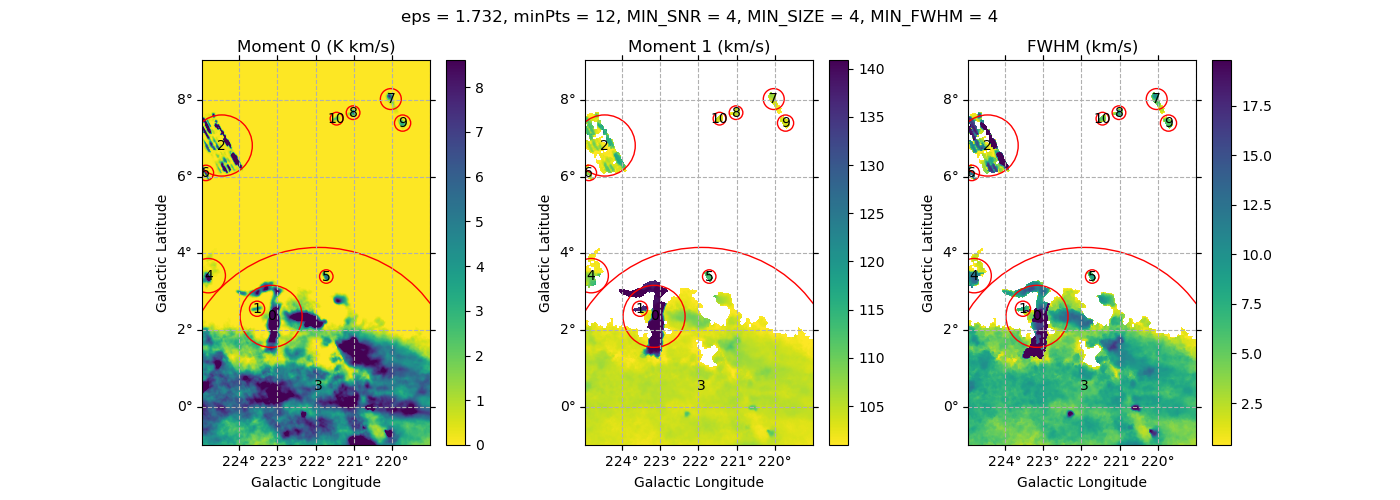

In [45]:
vyx_clusters = np.empty((0, 3))
for i in hvc_candidates:
    vyx = index[labels == i]  # 第i个cluster每个点的vyx坐标
    vyx_clusters = np.vstack((vyx_clusters, vyx))
vyx_clusters = vyx_clusters.astype(int)

bool_array = np.zeros(data.shape, dtype=np.bool_)
bool_array[vyx_clusters[:, 0], vyx_clusters[:, 1], vyx_clusters[:, 2]] = (
    True  # 对第i个cluster的每个点标记为True
)
hvc_candidates_cube = sc(bool_array * data_nan, wcs=wcs).with_spectral_unit(u.km / u.s)
# 如果把bool_array替换为mask，就会显示DBSCAN前的数据

size_pixels = (SIZE / pixel_to_arcmin) ** 2

fig, ax = plt.subplots(
    1,
    3,
    figsize=[14, 5],
    sharex=True,
    sharey=True,
    subplot_kw={"projection": wcs.celestial},
)  # subplot_kw={"projection": wcs.celestial}

moment_0 = np.array(hvc_candidates_cube.moment(order=0))
im0 = ax[0].imshow(
    moment_0, norm=simple_norm(moment_0, percent=95), cmap="viridis_r", origin="lower"
)
ax[0].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates):
    ax[0].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[0].grid(linestyle="--")
ax[0].set_title("Moment 0 (K km/s)")
ax[0].set_xlabel("Galactic Longitude")
ax[0].set_ylabel("Galactic Latitude")
plt.colorbar(im0)

moment_1 = np.array(hvc_candidates_cube.moment(order=1))
im1 = ax[1].imshow(
    moment_1, norm=simple_norm(moment_1, percent=95), cmap="viridis_r", origin="lower"
)
ax[1].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates):
    ax[1].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[1].grid(linestyle="--")
ax[1].set_title("Moment 1 (km/s)")
ax[1].set_xlabel("Galactic Longitude")
ax[1].set_ylabel("Galactic Latitude")
plt.colorbar(im1)

moment_2 = np.array(hvc_candidates_cube.linewidth_fwhm())
im2 = ax[2].imshow(
    moment_2, norm=simple_norm(moment_2, percent=95), cmap="viridis_r", origin="lower"
)
ax[2].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates):
    ax[2].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[2].grid(linestyle="--")
ax[2].set_title("FWHM (km/s)")
ax[2].set_xlabel("Galactic Longitude")
ax[2].set_ylabel("Galactic Latitude")
plt.colorbar(im2)

fig.suptitle(
    f"eps = {np.round(eps, 3)}, minPts = {min_samples}, MIN_SNR = {MIN_SNR}, "
    f"MIN_SIZE = {MIN_SIZE}, MIN_FWHM = {MIN_FWHM}"
)
plt.savefig("./Figures/cluster_moments.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# 对于一个cluster遍历速度轴，对每一个速度v计算所有像素的平均I_v
# 绘制I_v - v光谱图


def calc_spectrum(i, data, index, labels, total=False):
    vyx = index[labels == i]  # 第i个cluster每个点的vyx坐标
    bool_array_spec = np.zeros(data.shape, dtype=np.bool_)
    if total == True:  # 绘制整个速度区间的光谱
        bool_array_spec[:, vyx[:, 1], vyx[:, 2]] = True
    else:  # 仅绘制cluster所在速度区间的光谱
        bool_array_spec[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = True
    cluster_data = bool_array_spec * data
    cluster_data[cluster_data == 0] = np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        spectrum = np.nanmean(cluster_data, axis=(1, 2))
    spectrum = np.nan_to_num(spectrum)
    vel_array = (spectrum != 0)
    vel_array = vel_array * velocities
    non_zero_indices = (spectrum != 0) & (vel_array != 0)
    spectrum = spectrum[non_zero_indices]
    vel_array = vel_array[non_zero_indices]
    return vel_array, spectrum

In [47]:
# HIDPI 的光谱作对比
# 对于一个cluster遍历速度轴，对每一个速度v计算所有像素的平均I_v
# 绘制I_v - v光谱图

N_HVC = len(hvc_candidates)

vel_array_crafts = []
spectrum_crafts = []

vel_array_crafts_total = []
spectrum_crafts_total = []

vel_array_hi4pi = []
spectrum_hi4pi = []

for i in trange(N_HVC):
    vel_cr, spectrum_cr = calc_spectrum(hvc_candidates[i], data, index, labels, total=False)
    vel_cr_total, spectrum_cr_total = calc_spectrum(hvc_candidates[i], data, index, labels, total=True)
    vel_hi, spectrum_hi = calc_spectrum(hvc_candidates[i], hidpi_data_reproj, index, labels, total=True)
    vel_array_crafts.append(vel_cr)
    spectrum_crafts.append(spectrum_cr)
    vel_array_crafts_total.append(vel_cr_total)
    spectrum_crafts_total.append(spectrum_cr_total)
    vel_array_hi4pi.append(vel_hi)
    spectrum_hi4pi.append(spectrum_hi)

  0%|          | 0/11 [00:00<?, ?it/s]

### 使用高斯滤波和峰值寻找，根据峰值高度和对称性自动判断光谱信号的真实性

In [48]:
def find_response(x: np.ndarray, y: np.ndarray):
    # Generate the filter you want to match to in the data
    y_filtered = gaussian_filter(y, sigma=10)
    # Use scipy to find all the peaks in the filter response
    peaks, properties = find_peaks(y_filtered)
    # Capture the prominence of each peak (how much does the peak stick up)
    prominences, left_bases, right_bases = peak_prominences(y_filtered, peaks)
    # Find the maximum prominence (which hopefully matches our signal)
    max_prom_index = np.argmax(prominences)
    peak_prominence = prominences[max_prom_index]
    # Find the x-value that the peak occurred at
    main_peak_x = x[peaks[max_prom_index]]
    main_peak_y = y_filtered[peaks[max_prom_index]]
    # the left base of the peak
    main_lbase_x = x[left_bases[max_prom_index]]
    main_lbase_y = y_filtered[left_bases[max_prom_index]]
    # the right base of the peak
    main_rbase_x = x[right_bases[max_prom_index]]
    main_rbase_y = y_filtered[right_bases[max_prom_index]]
    main_peak_plot = [
        main_peak_x,
        main_peak_y,
        main_lbase_x,
        main_lbase_y,
        main_rbase_x,
        main_rbase_y,
    ]
    # 计算峰值的对称度：
    # 参数为峰值的左端点L、右端点R、峰值P
    # skew = |L + R - 2P| / |L - R|
    skew = np.abs(main_peak_plot[2] + main_peak_plot[4] - 2 * main_peak_plot[0])
    skew /= np.abs(main_peak_plot[2] - main_peak_plot[4])
    return y_filtered, main_peak_x, peak_prominence, main_peak_plot, skew

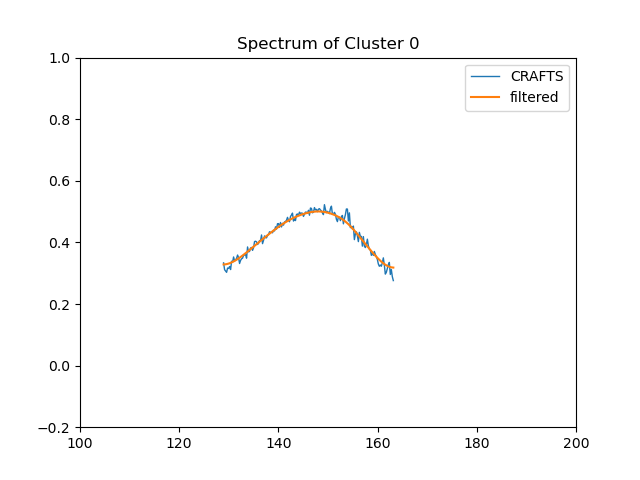

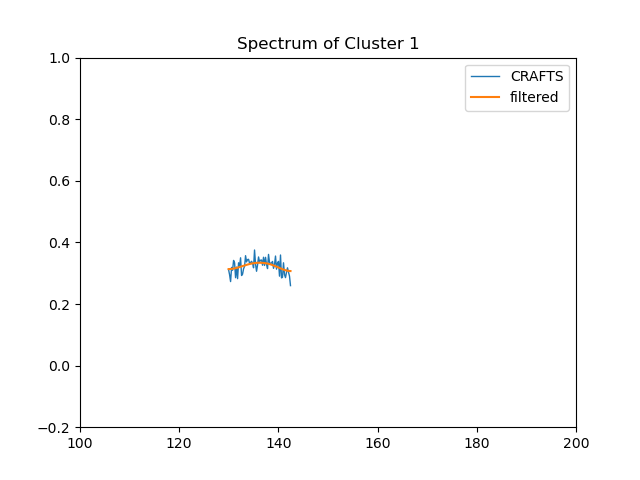

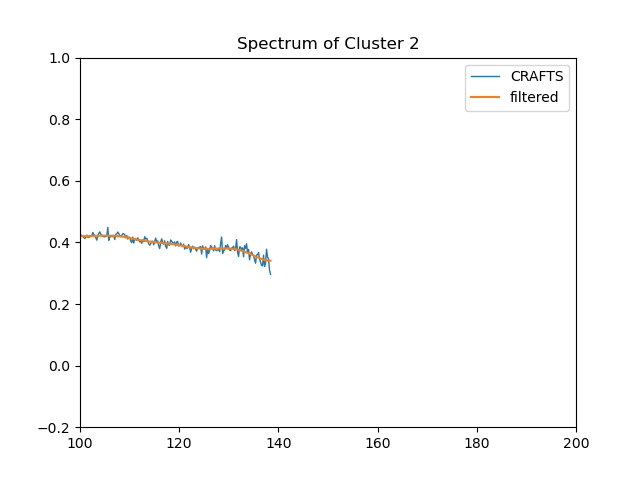

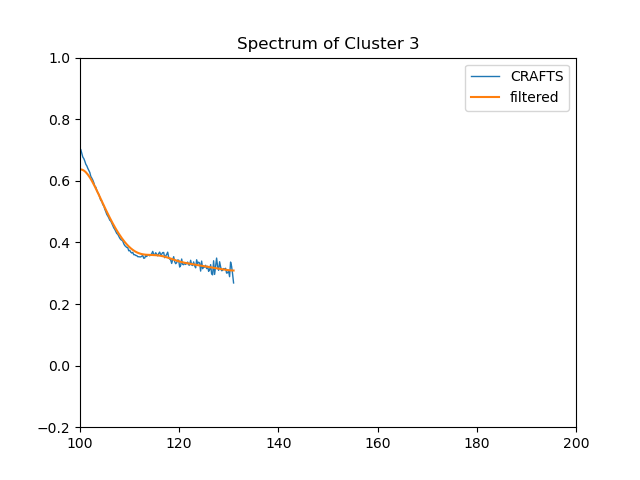

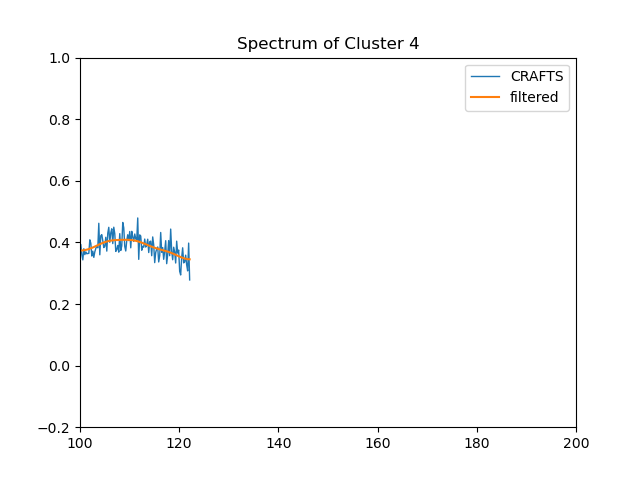

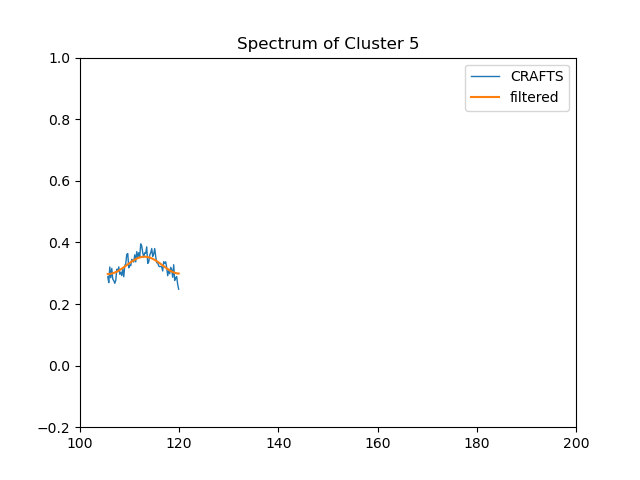

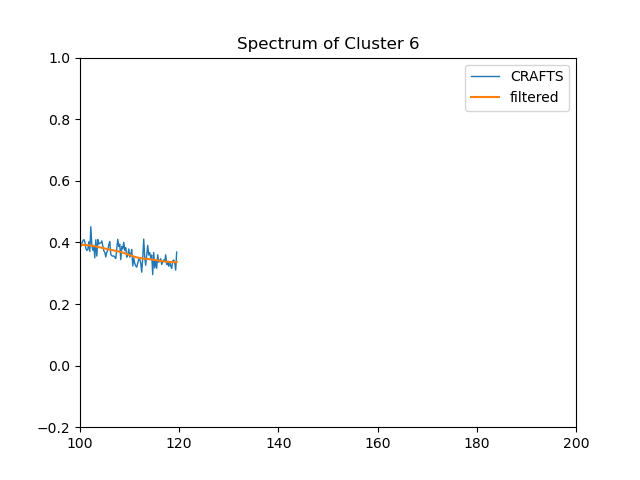

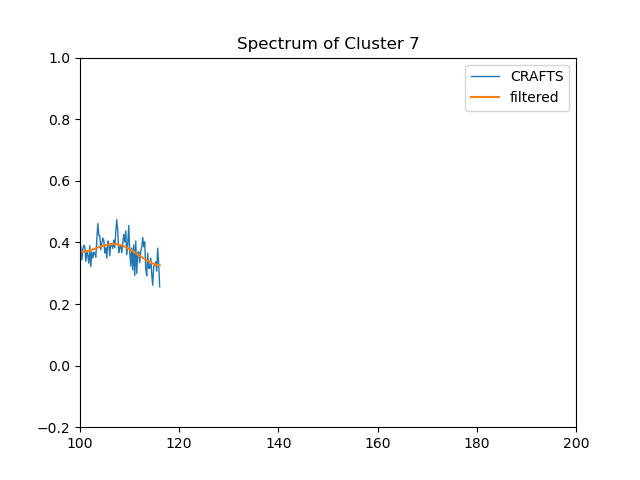

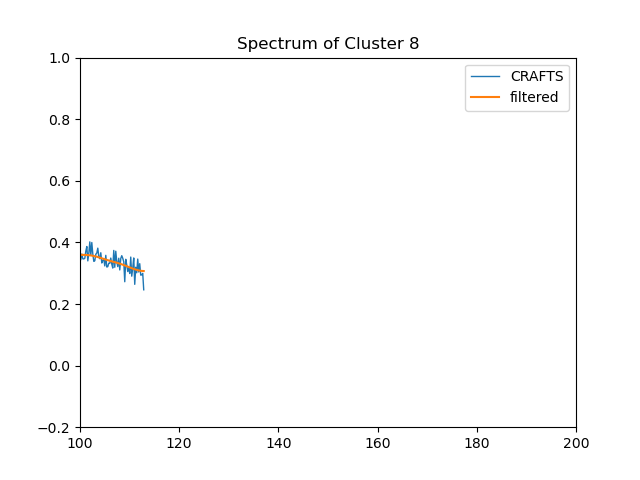

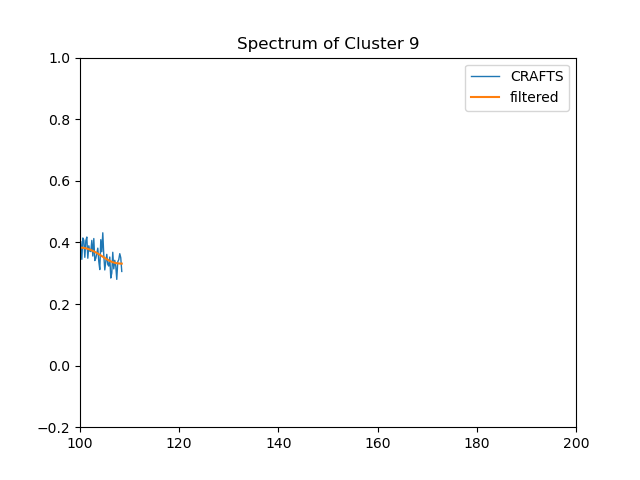

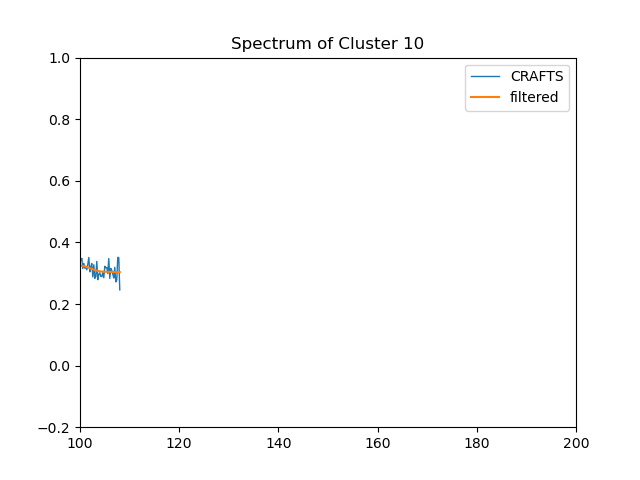

In [49]:
for i in range(N_HVC):
    # y_filtered, v_peak, peak_prominence, main_peak_plot, skew = find_response(
    #     vel_array_crafts[i], spectrum_crafts[i]
    # )
    fig = plt.figure()
    plt.plot(vel_array_crafts[i], spectrum_crafts[i], label="CRAFTS", lw=1)
    vel_width = vel_array_crafts[i][0] - vel_array_crafts[i][-1]
    if vel_width > 10:
        y_filtered = gaussian_filter(spectrum_crafts[i], sigma=10)
    else:
        y_filtered = gaussian_filter(spectrum_crafts[i], sigma=vel_width)
    plt.plot(vel_array_crafts[i], y_filtered, label="filtered", lw=1.5)
    plt.legend()
    plt.xlim(100, 200)
    plt.ylim(-0.2, 1)
    plt.title(f"Spectrum of Cluster {i}")
    plt.show()

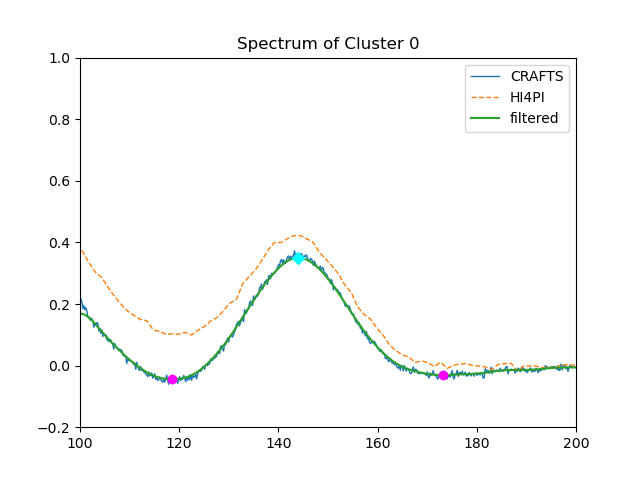

True signal
Cluster: 0, v_peak: 144.047 km/s, peak_prominence: 0.382, skew: 0.066


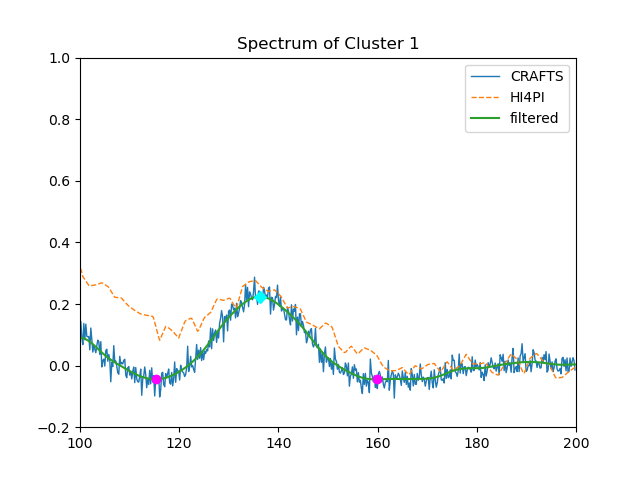

True signal
Cluster: 1, v_peak: 136.197 km/s, peak_prominence: 0.268, skew: 0.063


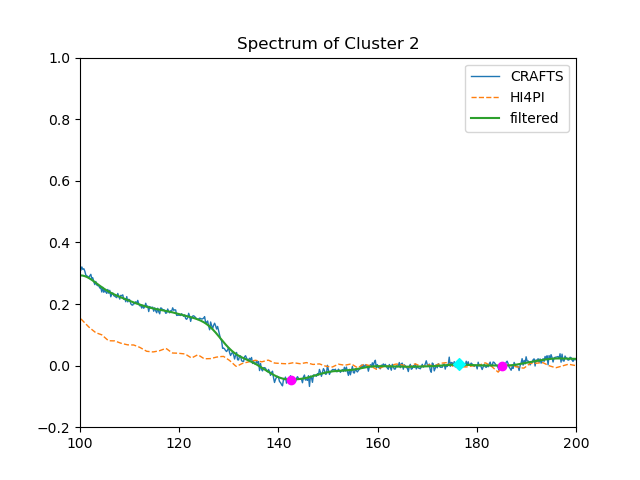

False signal
Cluster: 2, v_peak: 176.454 km/s, peak_prominence: 0.003, skew: 0.592


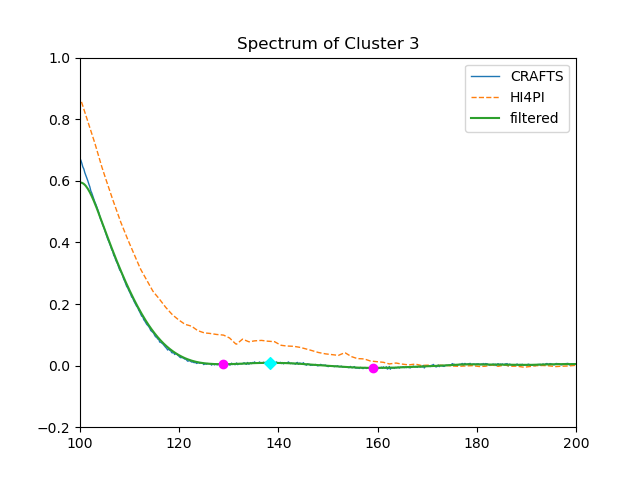

False signal
Cluster: 3, v_peak: 138.210 km/s, peak_prominence: 0.004, skew: 0.377


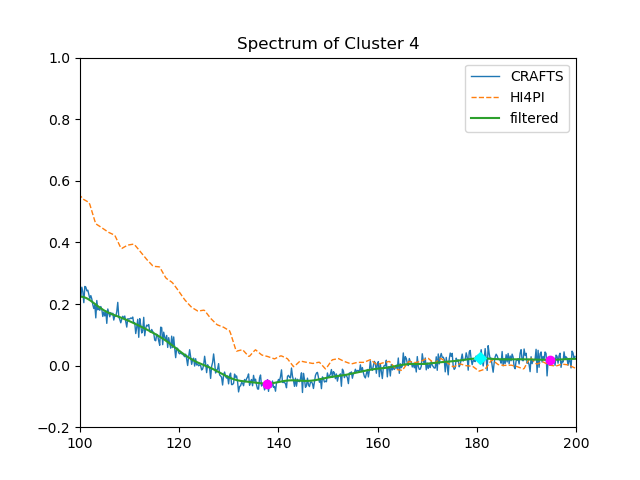

False signal
Cluster: 4, v_peak: 180.681 km/s, peak_prominence: 0.005, skew: 0.507


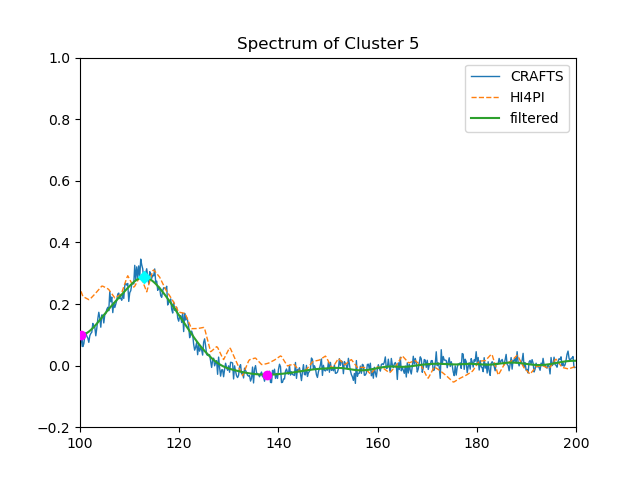

True signal
Cluster: 5, v_peak: 112.848 km/s, peak_prominence: 0.187, skew: 0.323


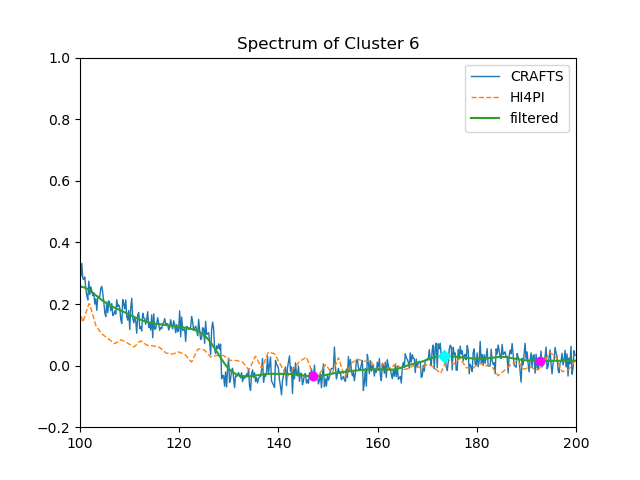

False signal
Cluster: 6, v_peak: 173.434 km/s, peak_prominence: 0.016, skew: 0.154


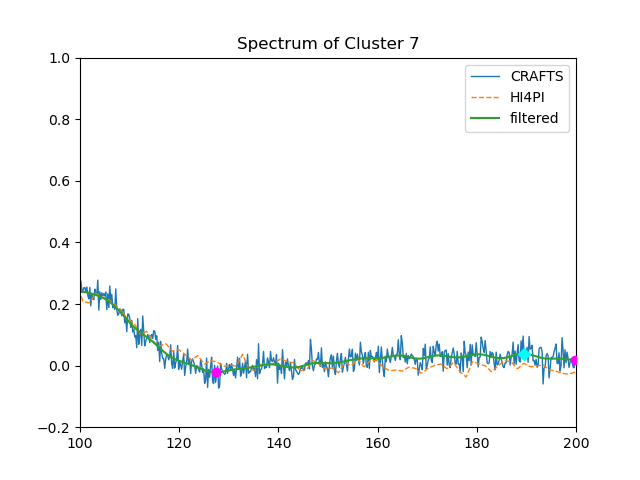

False signal
Cluster: 7, v_peak: 189.537 km/s, peak_prominence: 0.021, skew: 0.717


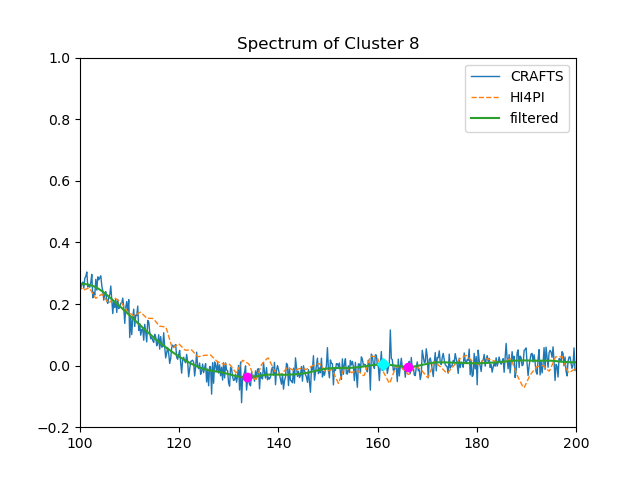

False signal
Cluster: 8, v_peak: 161.156 km/s, peak_prominence: 0.008, skew: 0.691


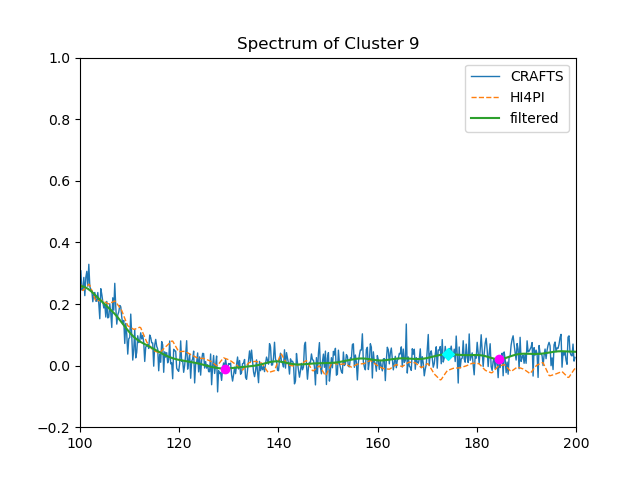

False signal
Cluster: 9, v_peak: 174.240 km/s, peak_prominence: 0.017, skew: 0.629


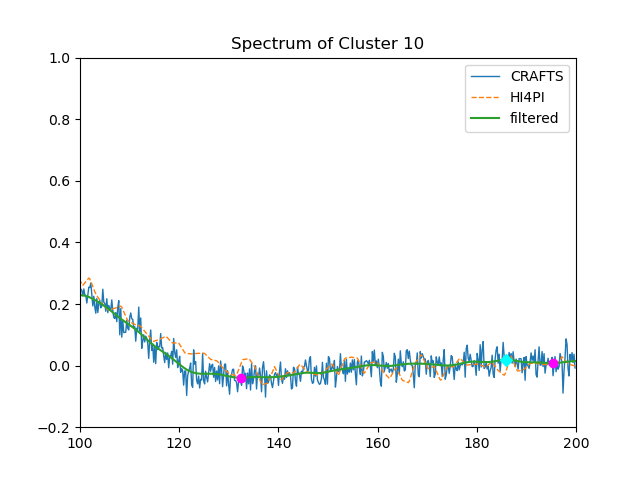

False signal
Cluster: 10, v_peak: 185.914 km/s, peak_prominence: 0.011, skew: 0.700
N_HVC = 11, F_HVC = 8, T_HVC = 3


In [50]:
F_HVC = 0
T_HVC = 0
PEAK_HEIGHT = []
PEAK_WIDTH = []

for i in range(N_HVC):
    y_filtered, v_peak, peak_prominence, main_peak_plot, skew = find_response(
        vel_array_crafts_total[i], spectrum_crafts_total[i]
    )
    fig = plt.figure()
    plt.plot(vel_array_crafts_total[i], spectrum_crafts_total[i], label="CRAFTS", lw=1)
    plt.plot(vel_array_hi4pi[i], spectrum_hi4pi[i], label="HI4PI", lw=1, ls="--")
    plt.plot(vel_array_crafts_total[i], y_filtered, label="filtered", lw=1.5)
    # plt.scatter(x[peaks], y_filtered[peaks], c="cyan", marker="+")
    plt.scatter(
        main_peak_plot[0],
        main_peak_plot[1],
        c="cyan",
        marker="D",
        zorder=100,
    )
    # plt.scatter(x[left_bases], y_filtered[left_bases], c="magenta", marker="+")
    plt.scatter(
        main_peak_plot[2],
        main_peak_plot[3],
        c="magenta",
        zorder=100,
    )
    # plt.scatter(x[right_bases], y_filtered[right_bases], c="magenta", marker="+")
    plt.scatter(
        main_peak_plot[4],
        main_peak_plot[5],
        c="magenta",
        zorder=100,
    )
    plt.legend()
    plt.xlim(100, 200)
    plt.ylim(-0.2, 1)
    plt.title(f"Spectrum of Cluster {i}")
    plt.show()
    if peak_prominence > 0.1 and skew < 0.6:
        print("True signal")
        PEAK_HEIGHT.append(peak_prominence)
        PEAK_WIDTH.append(np.abs(main_peak_plot[2] - main_peak_plot[4]))
    else:
        print("False signal")
        F_HVC += 1
    print(
        f"Cluster: {i}, v_peak: {v_peak:.3f} km/s, peak_prominence: {peak_prominence:.3f}, skew: {skew:.3f}"
    )


T_HVC = N_HVC - F_HVC
print(f"N_HVC = {N_HVC}, F_HVC = {F_HVC}, T_HVC = {T_HVC}")